# Project: Global COVID-19 Trend Analysis
## Introduction
This project explores the global impact of COVID-19, focusing on infection rates and peak periods across different nations. As my first data analysis project, the goal is to practice data cleaning, filtering, and visualization using Python.

**About the Dataset**

The data used in this analysis is sourced from Our World in Data (OWID). It is a collection of the COVID-19 data maintained by the Global Change Data Lab.
- Source: [Our World in Data COVID-19 Dataset](https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv)
- Key Metrics used: total_cases, new_cases_smoothed, location, and date.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data Acquisition
the data is loaded in to pandas dataframe for analysis

In [2]:
table = pd.read_csv('owid-covid-data.csv')

### Exploratory Data Analysis
before analysis, we inspect the structure of the dataframe to understand:
- dimensions(number of rows and columns)
- datatypes
- missing values that might need handling

In [3]:
table.shape

(429435, 67)

In [4]:
table.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [5]:
table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

### 1. Identifying the Highest Infection Counts
We filter the dataset to look specifically at countries (using the 3-letter ISO codes) 
to find which nation has recorded the highest total number of cases to date.

In [6]:
countries_only = table[table['iso_code'].str.len() == 3]
max_country_case = countries_only['total_cases'].max()
country_max = countries_only[countries_only['total_cases'] == max_country_case]
country_max.head(3)

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
404676,USA,North America,United States,2023-05-14,103436829.0,93260.0,13322.86,1127152.0,1943.0,277.57,...,24.6,NaN,2.77,78.86,0.93,338289856,1291446.6,12.88,2.29,3798.41
404677,USA,North America,United States,2023-05-15,103436829.0,0.0,13322.86,1127152.0,0.0,277.57,...,24.6,NaN,2.77,78.86,0.93,338289856,NaN,NaN,NaN,NaN
404678,USA,North America,United States,2023-05-16,103436829.0,0.0,13322.86,1127152.0,0.0,277.57,...,24.6,NaN,2.77,78.86,0.93,338289856,NaN,NaN,NaN,NaN


In [7]:
print(country_max.shape)
country_max['location'].value_counts()

(449, 67)


location
United States    449
Name: count, dtype: int64

In [8]:
most_total_case = country_max.loc[country_max['total_cases'].idxmax()]
country = most_total_case['location']
value = most_total_case['total_cases']
print(country, value)

United States 103436829.0


### the country with the most total cases, United States
### the number of cases, 103436829.0

### 2. Analyzing Mortality Impact
While total cases show the scale, the **death rate per million** highlights the severity 
relative to population size. We filter the data to identify the country with the 
highest mortality rate.

In [9]:
highest_death_rate = table['total_deaths_per_million'].max()
DF_highest_death_rate = table[table['total_deaths_per_million'] == highest_death_rate]
DF_highest_death_rate.head(3)

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
302641,PER,South America,Peru,2024-06-16,4526888.0,107.0,15.29,220975.0,1.0,0.14,...,NaN,NaN,1.6,76.74,0.78,34049588,NaN,NaN,NaN,NaN
302642,PER,South America,Peru,2024-06-17,4526888.0,0.0,15.29,220975.0,0.0,0.14,...,NaN,NaN,1.6,76.74,0.78,34049588,NaN,NaN,NaN,NaN
302643,PER,South America,Peru,2024-06-18,4526888.0,0.0,15.29,220975.0,0.0,0.14,...,NaN,NaN,1.6,76.74,0.78,34049588,NaN,NaN,NaN,NaN


In [10]:
print(DF_highest_death_rate.shape)
DF_highest_death_rate['location'].value_counts()

(50, 67)


location
Peru    50
Name: count, dtype: int64

In [11]:
max = DF_highest_death_rate.tail(1)['total_deaths_per_million']
country = DF_highest_death_rate.tail(1)['location']
print(country, max)

302690    Peru
Name: location, dtype: object 302690    6601.11
Name: total_deaths_per_million, dtype: float64


### the country with the highest death rate is, Peru
### The rate, 6601.11 total_death/ million

### 3. Visualizing the vaccination Progression
To better understand how the vaccination progressed between four countries, we visualize the `people_fully_vaccinated_per_hundred` over time 
for a selection of countries: the United Kingdom, United States, France, and Germany.

In [12]:
# Countries selected United Kingdom, United States, France, Germany

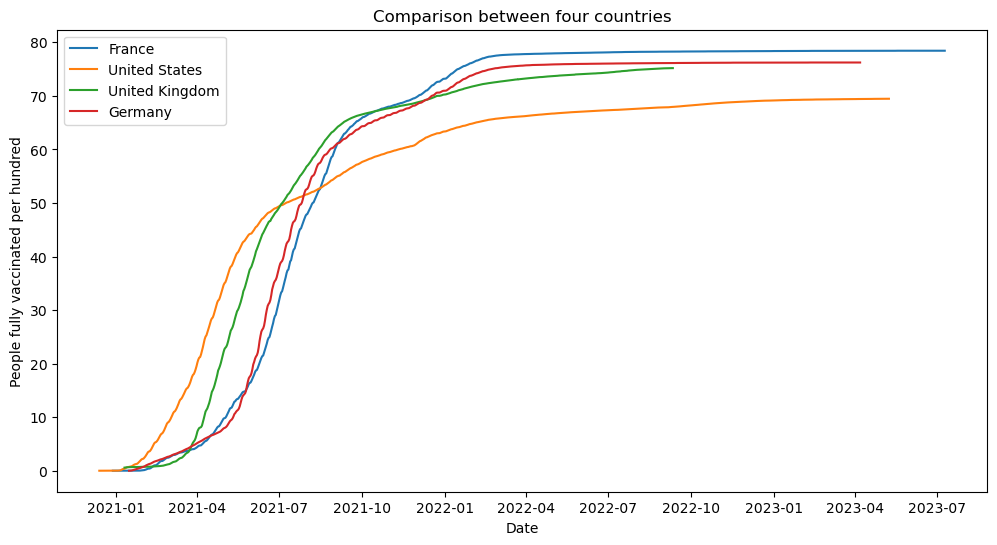

In [13]:
table['date'] = pd.to_datetime(table['date'])

FR = table[(table['location'] == 'France')]
US = table[(table['location'] == 'United States')]
UK = table[(table['location'] == 'United Kingdom')]
GER = table[(table['location'] == 'Germany')]

plt.figure(figsize = (12, 6))
plt.plot(FR['date'], FR['people_fully_vaccinated_per_hundred'], label = 'France')
plt.plot(US['date'], US['people_fully_vaccinated_per_hundred'], label = 'United States')
plt.plot(UK['date'], UK['people_fully_vaccinated_per_hundred'], label = 'United Kingdom')
plt.plot(GER['date'], GER['people_fully_vaccinated_per_hundred'], label = 'Germany')
plt.xlabel('Date')
plt.ylabel('People fully vaccinated per hundred')
plt.title('Comparison between four countries')
plt.legend()

### The percentage of people fully vaccinated per hundred was initially highest for the United States, followed by the United Kingdom.
### Over time, France and Germany gradually surpassed both, with France eventually reaching the highest value.

## 4. Peak infection date
here a dataframe illustraing the peak infection date is made by filtering the main dataset using the selected countries

In [14]:
countries = ['United Kingdom', 'United States', 'France', 'Germany']
df_countries = table[table['location'].isin(countries)]
result = []

for country in countries:
    country_df = df_countries[df_countries['location'] == country]
    peak_row = country_df.loc[country_df['new_cases_smoothed'].idxmax()]
    result.append({
        'Country': country,
        'Date': peak_row['date'],
        'Peak infection': peak_row['new_cases_smoothed']
    })

df = pd.DataFrame(result)
df.set_index('Country', inplace = True)

### DataFrame Showing the peak infection date and values for the selected countries

In [15]:
df

,Date,Peak infection
Country,,
United Kingdom,2022-01-09,188618.86
United States,2022-01-16,807276.14
France,2022-01-23,345291.86
Germany,2022-03-27,226984.43


### Conclusion and Insights
- **United States:** Recorded the highest absolute number of total cases.
- **Peru:** Faced the highest death rate relative to its population (per million).
- **Trends:** The visualization highlights distinct plot of vaccination across European nations 
and the US, showing how the percentage of fully vaccinated pepole per hundred varied by region.
- **Peak infection date:** a dataframe showing the peak infection dates and values of the selected counties is provided